In [1]:
import numpy as np
import matplotlib.pyplot as plt
import camb
import healpy as hp

In [1]:
import sys
print(sys.executable)

/data/vault/jv447/venvs/research-project/bin/python


In [ ]:
# Set up a new set of parameters for CAMB
# The defaults give one massive neutrino and helium set using BBN consistency
pars = camb.set_params(
    H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06, As=2e-9, ns=0.965, halofit_version='mead', lmax=3000
)
# calculate results for these parameters (stores e.g. transfer functions, power spectra, etc.)
results = camb.get_results(pars)

powers = results.get_cmb_power_spectra(pars, CMB_unit='muK',raw_cl=True)['total']

In [4]:

powers = results.get_cmb_power_spectra(pars, CMB_unit='muK',raw_cl=True)['total']

<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:5: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_14693/2131940686.py:4: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\ell$')
/tmp/ipykernel_14693/2131940686.py:5: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel('$C^{XX}_\ell$')


Text(0, 0.5, '$C^{XX}_\\ell$')

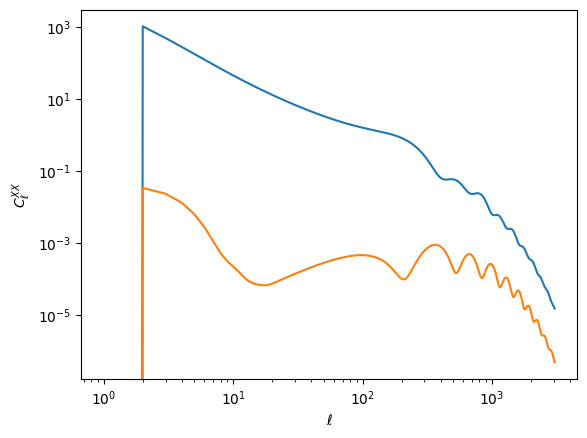

In [9]:
plt.loglog(powers[:,0],label='Intensity (T)')
plt.loglog(powers[:,1],label='E-mode polarization (E)')
#plt.loglog(powers[:,3])
plt.xlabel('$\ell$')
plt.ylabel('$C^{XX}_\ell$')

## Simple simulator

In [5]:
def generateMock(cl,nls=None,lmax=3000,beam_fwhm=0):
    """
      could put camb call into here too.
      nls a list of noise spectra for each split [nl,nl...].
      Beams are a second observational effect. 1-7 is a reasonable value. Could also be different per split... """
    cmb_alm = hp.synalm(cl,lmax=lmax) # generates a 2d spherical sky map from 1d spectrum
    if beam_fwhm is not None and beam_fwhm!=0:
        beam = hp.gauss_beam(beam_fwhm/60/180*np.pi,lmax=lmax) # simulates telescope blur with a gaussian blur and appliies to sky map
    else:
        beam=np.ones(3000)
        #cmb_alm = hp.almxfl(
    if nls is not None:
        obs_alms = []
        for nl in nls:
            noise = hp.synalm(nl,lmax=lmax) # telescope's electronic noise
            obs_alms.append(hp.almxfl(cmb_alm,beam)+noise) # combine blur plus noise
        return np.array(obs_alms)
    else:
        return cmb_alm

In [6]:
beam_fwhm = 5.
nl = np.ones(5000)*(20/60/180*60)**2 # White noise spectrum
alms = generateMock(powers[:,0],nls=[nl,1.3*nl],beam_fwhm=beam_fwhm)

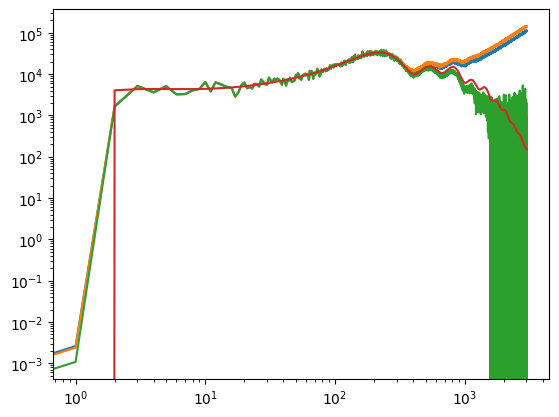

In [ ]:
plt.loglog(np.arange(3001),np.arange(3001)**2*hp.alm2cl(alms[0]))
plt.loglog(np.arange(3001),np.arange(3001)**2*hp.alm2cl(alms[1]))
plt.loglog(np.arange(3001),np.arange(3001)**2*hp.alm2cl(alms[0],alms[1]))
plt.loglog(np.arange(3001),np.arange(3001)**2*powers[:3001,0],label='Intensity (T)')

# Compression

In [7]:
param_dict={
    "H0":67.5, "ombh2":0.022, "omch2":0.122, "mnu":0.06, "omk":0, "tau":0.06, "As":2e-9, "ns":0.965, "halofit_version":'mead', "lmax":3000
}

In [8]:
# which parameters to vary for compression. The value is a fractional step size for numerical derivatives
derivatives = {"H0":0.001, "ombh2":0.005, "omch2":0.005,"As":0.005, "ns":0.005} 

In [9]:
# Note I convert As to As 10^10 in the derivatives to give more reasonable numbers.

def getCompression(param_dict,derivatives,beam_fwhm=None,noise_cl=None):
    """ 
    A simple implementation of the moped algorithm. This assumes no dependence of cov mat on parameters (e.g. https://arxiv.org/pdf/1204.4724)
    Compute derivatives numerically
    Compute the cov mat based on a gaussian formalua. 
    Compressor is then \nabla \mu C^{-1} (d-\mu). 
    Note: Match the beam and noise to the splits above.
    This is a close to optimal compression around the fiducial cosmology. Maybe use an SBI prior is some region around here. Planck +3 sigma?
    """
    
    lmax=param_dict['lmax']
    def getSpectrum(params): # similar function to generateMock, adds some noise
        pars = camb.set_params(**params)
        results = camb.get_results(pars)
        powers = results.get_cmb_power_spectra(pars, CMB_unit='muK',raw_cl=True)['total'][2:3001,0]
        if noise_cl is None:
            noise=0
        else:
            noise=noise_cl[2:3001]
        if beam_fwhm is not None:
            beam = hp.gauss_beam(beam_fwhm/60/180*np.pi,lmax=lmax)[2:]
        else:
            beam = np.ones(3001)[2:]
    
        return powers*beam**2+noise # Add in the effect of beam and noise if you want them
    fiducial = getSpectrum(param_dict) # run simulation once to obtain "expected" observation
    cov_mat = 2./(2*np.arange(2,3001)+1)*fiducial**2 # Gaussian cov mat.: error dominated by cosmic variance (have one universe to look at, 2/(2l+1)*C_ell^2)
    derivs = []
    for deriv_name in derivatives.keys():
        step = param_dict[deriv_name]*derivatives[deriv_name]
        deriv_params = dict(param_dict)
        deriv_params[deriv_name]+=step
        up = getSpectrum(deriv_params)
        deriv_params = dict(param_dict)
        deriv_params[deriv_name]-=step
        down = getSpectrum(deriv_params)
        if deriv_name=='As': step*=1e10 # Different "units" for this to adjust ranges of scales (measuring As 10^10 instead of As)
        derivs.append((up-down)/(2*step)) # we calculate gradients by finding difference beteeen slight nudge up and down
        print(deriv_name)
    derivs = np.array(derivs)
    def compressor(data):
        data = data[2:]# Remove first two elements, monopole and dipoel
        return  np.dot(derivs,(data-fiducial)/cov_mat) 
    return fiducial,cov_mat,derivs,compressor

<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_832/3731975712.py:4: SyntaxWarning: invalid escape sequence '\m'
  """


In [10]:
test = getCompression(param_dict,derivatives,beam_fwhm=beam_fwhm,noise_cl=nl)

H0
ombh2
omch2
As
ns


In [17]:
compressor = test[-1]

In [18]:
test[-1](hp.alm2cl(alms[0]))

array([ 1.03832104e+00, -1.84536839e+03, -3.87886442e+01,  2.26469650e+00,
       -1.64050864e+02])

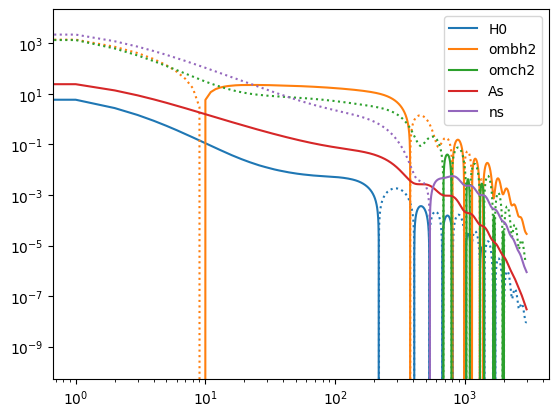

In [19]:
for i in range(5): 
    c = plt.loglog(test[2][i],label=list(derivatives.keys())[i])
    c = plt.loglog(-test[2][i],color=c[-1].get_color(),linestyle=':')
plt.legend()

In [20]:
test[2]

array([[ 1.53308430e+01,  5.85255131e+00,  2.73312117e+00, ...,
        -9.29696582e-09, -9.30569571e-09, -9.31433766e-09],
       [-3.20324442e+03, -1.39541392e+03, -7.26560396e+02, ...,
         2.89613861e-05,  2.88921781e-05,  2.88224362e-05],
       [-3.56417386e+03, -1.34468403e+03, -6.22317747e+02, ...,
        -2.55449943e-06, -2.56213512e-06, -2.56964511e-06],
       [ 5.08549467e+01,  2.40872919e+01,  1.36696431e+01, ...,
         3.02448648e-08,  3.00949429e-08,  2.99456719e-08],
       [-4.88567587e+03, -2.20818497e+03, -1.20186121e+03, ...,
         8.96627029e-07,  8.92613921e-07,  8.88602400e-07]],
      shape=(5, 2999))

## Simple check with Fisher forecast

In [21]:
cov_fisher = np.linalg.inv(np.einsum('ik,k,jk',test[2],1/test[1],test[2]))

In [22]:
derivatives.keys()

dict_keys(['H0', 'ombh2', 'omch2', 'As', 'ns'])

In [23]:
np.diag(cov_fisher)**.5

array([1.46740420e+00, 3.23751244e-04, 3.04246089e-03, 1.49319122e-01,
       8.98644042e-03])

In [24]:
np.log(2e-9*1e10+1.49315547e-01)-np.log(2e-9*1e10)

np.float64(0.0074380463709604605)

Generating Normal Sky Map...
Generating Perturbed Sky Map...


/tmp/ipykernel_777/763811501.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


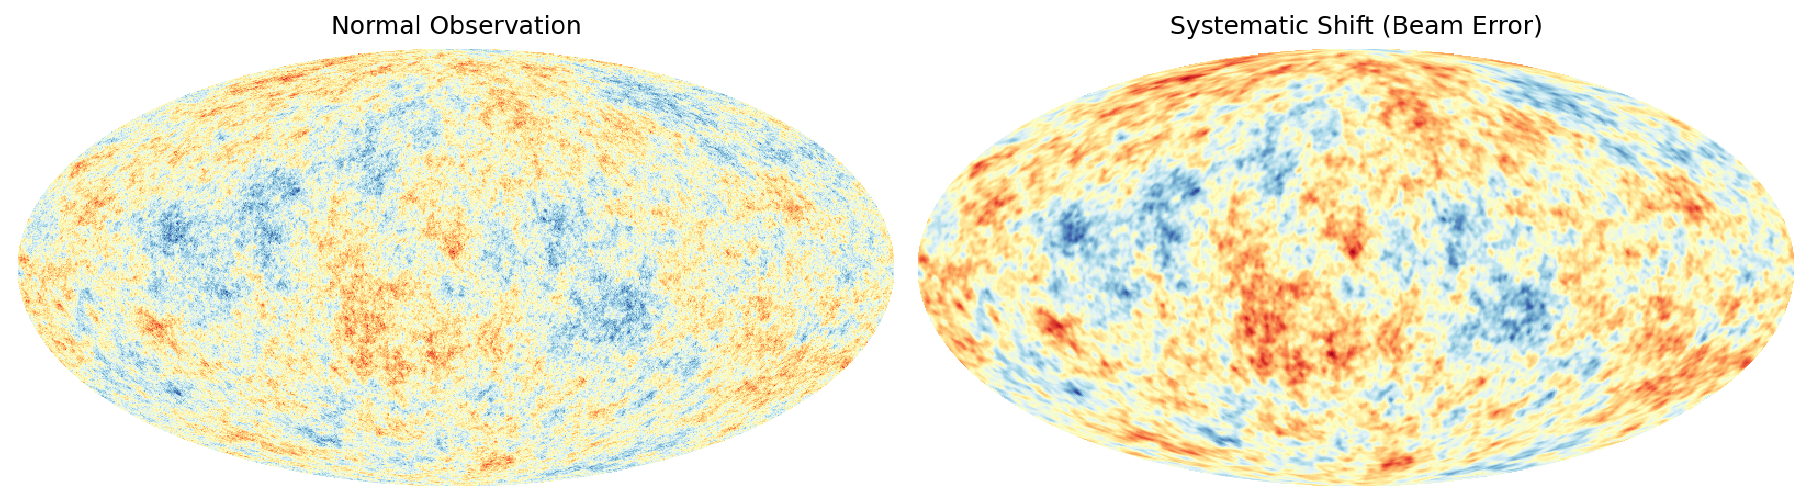

In [2]:
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. GENERATE SYNTHETIC SPECTRA
# ==========================================
# We create a synthetic baseline spectrum so this script runs anywhere
lmax = 800
ell = np.arange(0, lmax + 1)

cl_normal = np.zeros_like(ell, dtype=float)
# A standard approximation for the CMB temperature spectrum shape
cl_normal[2:] = 1.0 / (ell[2:] * (ell[2:] + 1)) 

# Create the "Perturbed" spectrum (Simulating a severe beam miscalibration)
# We multiply by a gaussian drop-off to artificially blur the small details
blurry_beam = np.exp(-ell**2 / (2 * 80**2)) # Exaggerated for the visual!
cl_perturbed = cl_normal * blurry_beam

# ==========================================
# 2. GENERATE 2D SKY MAPS
# ==========================================
nside = 256 # Standard resolution for the map

print("Generating Normal Sky Map...")
np.random.seed(42) # Lock the seed so the underlying universe is identical
map_normal = hp.synfast(cl_normal, nside=nside, lmax=lmax)

print("Generating Perturbed Sky Map...")
np.random.seed(42) # Use the EXACT SAME seed to isolate the systematic effect
map_perturbed = hp.synfast(cl_perturbed, nside=nside, lmax=lmax)

# ==========================================
# 3. PRESENTATION PLOTTING
# ==========================================
fig = plt.figure(figsize=(12, 6), dpi=150)



# Plot 1: Normal Observation
# Note: 'Plancks' is the official color map used by CMB cosmologists!
hp.mollview(map_normal, sub=(1, 2, 1), title="Normal Observation", 
            cmap='RdYlBu_r', format='%.1g', cbar=False)

# Plot 2: Perturbed Observation (Beam Error)
hp.mollview(map_perturbed, sub=(1, 2, 2), title="Systematic Shift (Beam Error)", 
            cmap='RdYlBu_r', format='%.1g', cbar=False)

plt.tight_layout()
plt.show()

Generating Normal Sky Map...
Generating Perturbed Sky Map...


/tmp/ipykernel_832/239279671.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


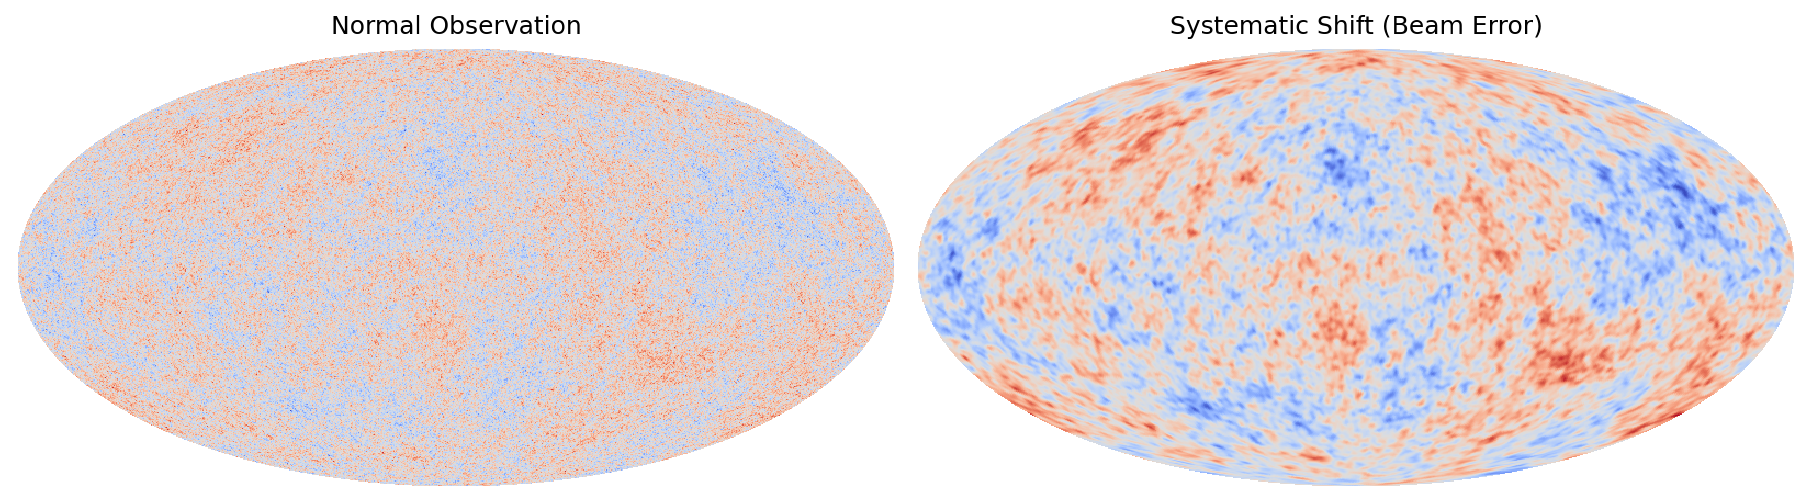

In [11]:
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. GRAB YOUR CAMB SPECTRUM FROM YOUR COMPRESSOR
# ==========================================
# 'test[0]' is the fiducial C_ell array from your getCompression function!
fiducial_cl_from_notebook = test[0] 

# Healpy needs the array to start at l=0, so we add two zeros at the front
cl_normal = np.zeros(len(fiducial_cl_from_notebook) + 2)
cl_normal[2:] = fiducial_cl_from_notebook

lmax = len(cl_normal) - 1
ell = np.arange(0, lmax + 1)

# Create the "Perturbed" spectrum (Simulating a severe beam miscalibration)
# We multiply by a gaussian drop-off to artificially blur the small details
blurry_beam = np.exp(-ell**2 / (2 * 60**2)) # Adjusted for a realistic visual
cl_perturbed = cl_normal * blurry_beam

# ==========================================
# 2. GENERATE 2D SKY MAPS
# ==========================================
nside = 256 

print("Generating Normal Sky Map...")
np.random.seed(42) 
map_normal = hp.synfast(cl_normal, nside=nside, lmax=lmax)

print("Generating Perturbed Sky Map...")
np.random.seed(42) 
map_perturbed = hp.synfast(cl_perturbed, nside=nside, lmax=lmax)

# ==========================================
# 3. PRESENTATION PLOTTING
# ==========================================
fig = plt.figure(figsize=(12, 6), dpi=150)

# 'coolwarm' perfectly mimics the standard cosmology color scheme
hp.mollview(map_normal, sub=(1, 2, 1), title="Normal Observation", 
            cmap='coolwarm', format='%.1g', cbar=False)

hp.mollview(map_perturbed, sub=(1, 2, 2), title="Systematic Shift (Beam Error)", 
            cmap='coolwarm', format='%.1g', cbar=False)

plt.tight_layout()
plt.show()